# Load Data

In [3]:
from pathlib import Path

test_normal_imgs = Path("test/NORMAL")
test_pneumonia_imgs = Path("test/PNEUMONIA")

train_normal_imgs = Path("train/NORMAL")
train_pneumonia_imgs = Path("train/PNEUMONIA")

val_normal_imgs = Path("val/NORMAL")
val_pneumonia_imgs = Path("val/PNEUMONIA")

# Data Visualisation
## Distribution


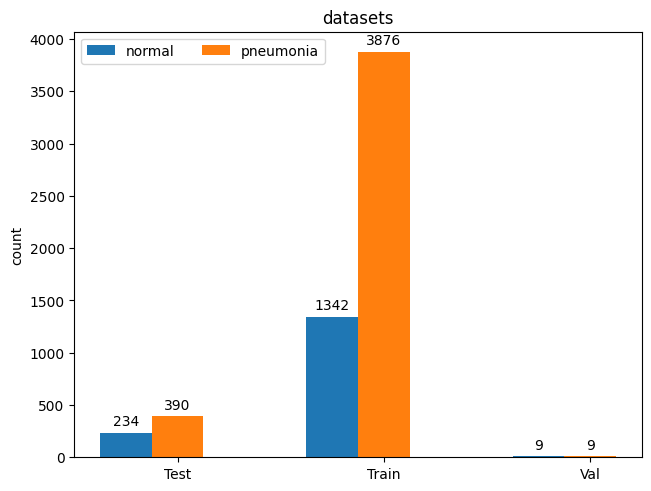

In [4]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ("Test", "Train", "Val")

list_test_normal_imgs = list(test_normal_imgs.iterdir())
list_test_pneumonia_imgs = list(test_pneumonia_imgs.iterdir())
list_train_normal_imgs = list(train_normal_imgs.iterdir())
list_train_pneumonia_imgs = list(train_pneumonia_imgs.iterdir())
list_val_normal_imgs = list(val_normal_imgs.iterdir())
list_val_pneumonia_imgs = list(val_pneumonia_imgs.iterdir())

def display_distribution(list_test_normal_imgs : list[Path], list_test_pneumonia_imgs : list[Path], list_train_normal_imgs : list[Path], list_train_pneumonia_imgs : list[Path], list_val_normal_imgs : list[Path], list_val_pneumonia_imgs : list[Path]):
    groups = {
        'normal': (len(list_test_normal_imgs), len(list_train_normal_imgs), len(list_val_normal_imgs)),
        'pneumonia': (len(list_test_pneumonia_imgs), len(list_train_pneumonia_imgs), len(list_val_pneumonia_imgs)),
    }


    x = np.arange(len(datasets))  
    width = 0.25 
    multiplier = 0

    _, ax = plt.subplots(layout='constrained')

    for attribute, measurement in groups.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.set_ylabel('count')
    ax.set_title('datasets')
    ax.set_xticks(x + width, datasets)
    ax.legend(loc='upper left', ncols=3)

    plt.show()

display_distribution(list_test_normal_imgs, list_test_pneumonia_imgs, list_train_normal_imgs, list_train_pneumonia_imgs, list_val_normal_imgs, list_val_pneumonia_imgs)

# Dataset
## train2val

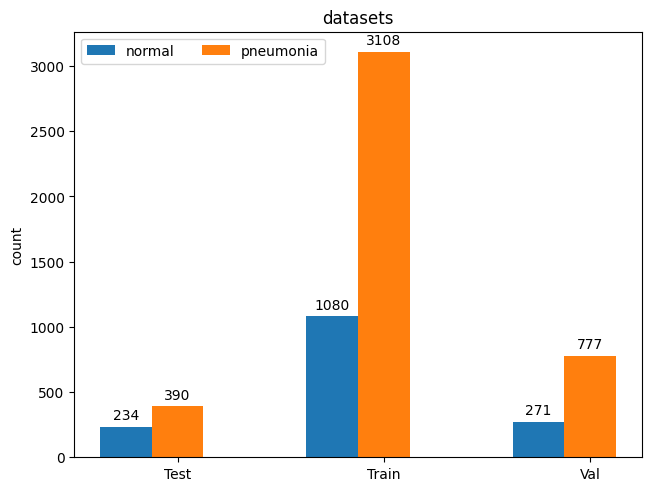

In [5]:
from sklearn.model_selection import train_test_split

list_train_normal_imgs.extend(list_val_normal_imgs)
list_val_normal_imgs = []
list_train_normal_imgs, list_val_normal_imgs = train_test_split(list_train_normal_imgs, test_size=0.2)
list_train_pneumonia_imgs.extend(list_val_pneumonia_imgs)
list_val_pneumonia_imgs = []
list_train_pneumonia_imgs, list_val_pneumonia_imgs = train_test_split(list_train_pneumonia_imgs, test_size=0.2)


display_distribution(list_test_normal_imgs, list_test_pneumonia_imgs, list_train_normal_imgs, list_train_pneumonia_imgs, list_val_normal_imgs, list_val_pneumonia_imgs)
